In [1]:
from scipy.optimize import curve_fit
import numpy as np
import matplotlib.pyplot as plt
from scipy import constants

# Función para el c+alculo de h y su propagación del error.

In [12]:
def calculo_h(lambda_a, V_e, eta):
  V_t = (constants.k * 287) / constants.e
  h = ((lambda_a * constants.e)/constants.c)*(V_e + (eta * V_t))
  return h

def prop(lambd, delta_lambd, v_e, delta_v_e, eta, delta_eta):
  v_t = (constants.k * 287) / constants.e
  parcial_lambd = (constants.e / constants.c) * (v_e + (eta * v_t))
  parcial_v_e = ((lambd * constants.e) / constants.c)
  parcial_eta = ((lambd * constants.e) / constants.c) * v_t
  delta_h = np.sqrt((parcial_lambd**2 * delta_lambd**2) + (parcial_v_e**2 * delta_v_e**2) + (parcial_eta**2 * delta_eta**2))
  return delta_h

# LED AZUL

## Cálculo de eta

Utilizando la ley de Ohm.

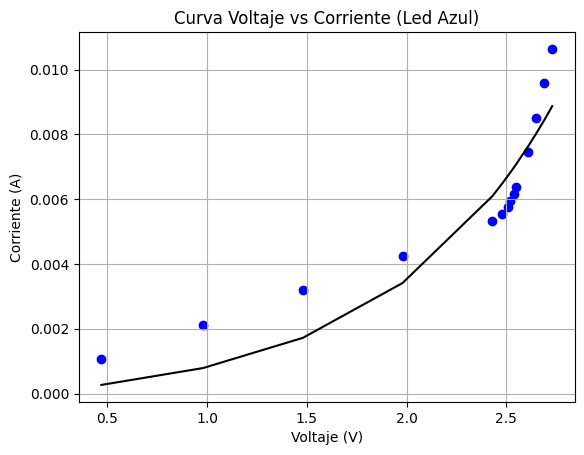

eta es: 33.863476551806436
El error de eta es: 9.536260394364087
I_s es: 0.0003542216045742842
El error de I_s es: 0.0003217309257777275


In [4]:
#datos
Voltaje = np.array([0.5, 1, 1.5, 2, 2.5, 2.6, 2.7, 2.8, 2.9, 3, 3.5, 4, 4.5, 5])
V_a= np.array([0.47, 0.98 ,1.48,1.98, 2.43, 2.48, 2.51, 2.52, 2.54, 2.55, 2.61, 2.65, 2.69, 2.73])

#ley de Ohm
R = 470
I = Voltaje/R

#Funcion del diodo
def intensidad2(V_a, eta, I_s):
    V_temp = (constants.k * 287) / constants.e #Calculo la V térmico
    I = I_s * (np.exp(V_a / (V_temp * eta)) - 1) #Función del diodo
    return I
#Valores de referencia
p0 = [3.060, 1e-12]

#Ajuste no-lineal
popt, pcov = curve_fit(intensidad2, V_a, I, p0=p0, maxfev=10000)

#Función del diodo
funcionn = intensidad2(V_a, popt[0], popt[1])

#error de eta y I_s
err_azul = np.sqrt(np.diag(pcov))

#Gráfico
plt.title('Curva Voltaje vs Corriente (Led Azul)')
plt.plot(V_a, funcionn, color ='black')
plt.scatter(V_a, I, color='blue')

plt.xlabel('Voltaje (V)')
plt.ylabel('Corriente (A)')
plt.grid()
plt.show()

print('eta es:',popt[0])
print('El error de eta es:',err_azul[0])
print('I_s es:',popt[1])
print('El error de I_s es:',err_azul[1])

Utilizando el amperímetro

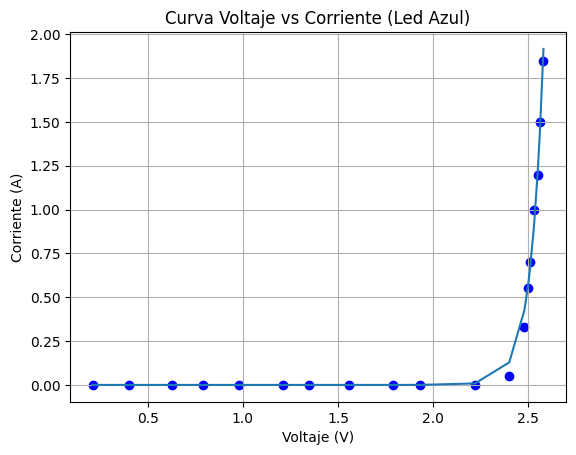

Valor de eta: 2.693219320872329 y el error es: 0.10733389064093354
Valor de Is: 2.887438083832754e-17 y el error es: 4.4186153625439244e-17


In [6]:
I_a = np.array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.05, 0.33, 0.55, 0.7, 1, 1.2, 1.5, 1.85])
V_a = np.array([0.21, 0.4, 0.63, 0.79, 0.98, 1.21, 1.35, 1.56, 1.79, 1.93, 2.22, 2.4, 2.48, 2.5, 2.51, 2.53, 2.55, 2.56, 2.58])

#Funcion del diodo
def intensidad1(V_a, eta, I_s):
    V_temp = (constants.k * 287) / constants.e #Calculo la V térmica
    I_a = I_s * (np.exp(V_a / (V_temp * eta)) - 1) #Función del diodo
    return I_a
#Valores de referencia
p0 = [3, 1e-12]

#Ajuste no-lineal
popt, pcov = curve_fit(intensidad1, V_a, I_a, p0=p0)

#Función del diodo
funcionn = intensidad1(V_a, popt[0], popt[1])

#errores
eta_err = np.sqrt(np.diag(pcov))

#Gráfico
plt.title('Curva Voltaje vs Corriente (Led Azul)')
plt.plot(V_a, funcionn)
plt.scatter(V_a, I_a, color='blue')

plt.xlabel('Voltaje (V)')
plt.ylabel('Corriente (A)')
plt.grid()
plt.show()

print(f'Valor de eta: {popt[0]} y el error es: {eta_err[0]}')
print(f'Valor de Is: {popt[1]} y el error es: {eta_err[1]}')

## Cálculo de V_e

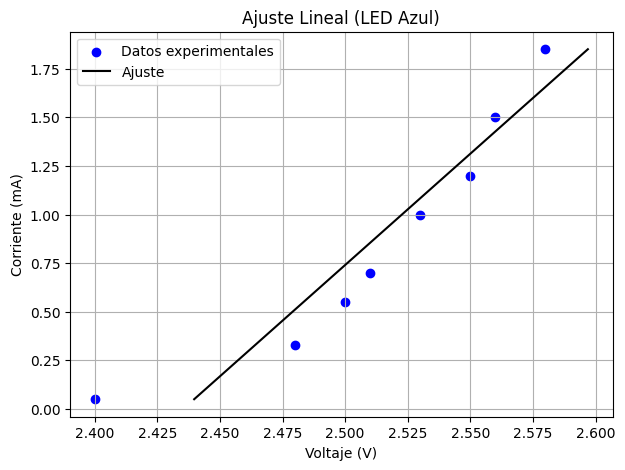

V_e: 2.4353602743541094 y R_e: 87.34231374404058
error de v_e_azul = 0.014206577907881825


In [9]:
I_a = np.array([0.00005, 0.00033, 0.00055, 0.0007, 0.001, 0.0012, 0.0015, 0.00185]) #A
I_A = I_a * 1e3 #mA
V_a = np.array([2.4, 2.48, 2.5, 2.51, 2.53, 2.55, 2.56, 2.58])

def ajuste_lineal(I, V_e, R_e):
  return V_e + R_e * I

p0 = [2.586, 183]

popt_lin_azul, pcov_lin_azul = curve_fit(ajuste_lineal, I_a, V_a, p0 = p0)

lineal_azul = ajuste_lineal(I_a, popt_lin_azul[0], popt_lin_azul[1])

plt.figure(figsize=(7, 5))
plt.title('Ajuste Lineal (LED Azul)')
plt.scatter(V_a, I_A, color='blue', label='Datos experimentales')
plt.plot(lineal_azul, I_A, color='black', label='Ajuste')

plt.xlabel('Voltaje (V)')
plt.ylabel('Corriente (mA)')
plt.grid(True)
plt.legend()
plt.show()

v_e_err_azul = np.sqrt(np.diag(pcov_lin_azul))

print(f'V_e: {popt_lin_azul[0]} y R_e: {popt_lin_azul[1]}')
print(f'error de v_e_azul = {v_e_err_azul[0]}')

## Calculo de h

In [15]:
lambd_azul = 473e-9
delta_lambd_azul = 23e-9
v_e_azul = 2.43536
delta_ve_azul = 0.014
eta_azul = 2.693
delta_eta_azul = 0.11

h_azul = calculo_h(lambd_azul, popt_lin_azul[0], popt[0])

err_h_azul = prop(lambd_azul, delta_lambd_azul, v_e_azul, delta_ve_azul, eta_azul, delta_eta_azul)

print(f'h = ({h_azul} +/- {err_h_azul}) Js')

h = (6.324593727316871e-34 +/- 3.0964360516155286e-35) Js


# LED ROJO

## Cálculo de eta

Utilizando la ley de Ohm.

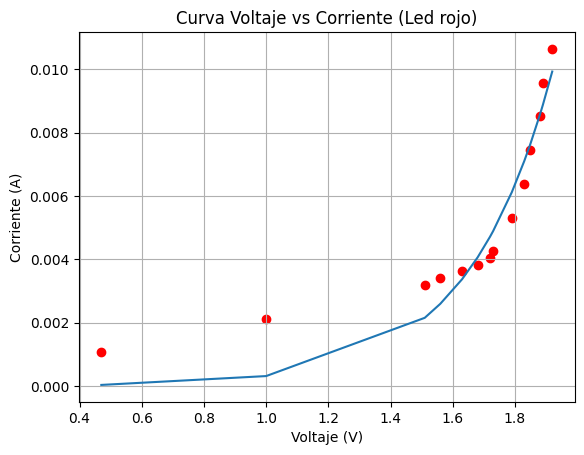

eta es: 10.873399546406809
El error de eta es: 1.346181043316636
I_s es: 7.875833332477024e-06
El error de I_s es: 6.678438356827919e-06


In [5]:
#datos
Voltaje = np.array([0.5, 1, 1.5, 1.6, 1.7, 1.8, 1.9, 2, 2.5, 3, 3.5, 4, 4.5, 5])
V_r = np.array([0.47, 1 ,1.51,1.56, 1.63, 1.68, 1.72, 1.73, 1.79, 1.83, 1.85, 1.88, 1.89, 1.92])

#ley de Ohm
R = 470
I = Voltaje/R

#Funcion del diodo
def intensidad1(V_r, eta, I_s):
    V_temp = (constants.k * 287) / constants.e #Calculo la V térmica
    I = I_s * (np.exp(V_r / (V_temp * eta)) - 1) #Función del diodo
    return I
#Valores de referencia
p0 = [2, 1e-12]

#Ajuste no-lineal
popt, pcov = curve_fit(intensidad1, V_r, I, p0=p0, maxfev=10000)

#Función del diodo
funcionn = intensidad1(V_r, popt[0], popt[1])

#error de eta y I_s
err_rojo = np.sqrt(np.diag(pcov))

#Gráfico
plt.title('Curva Voltaje vs Corriente (Led rojo)')
plt.plot(V_r, funcionn)
plt.scatter(V_r, I, color='red')

plt.xlabel('Voltaje (V)')
plt.ylabel('Corriente (A)')
plt.grid()
plt.show()

print('eta es:',popt[0])
print('El error de eta es:',err_rojo[0])
print('I_s es:',popt[1])
print('El error de I_s es:',err_rojo[1])

Utilizando el amperímetro.

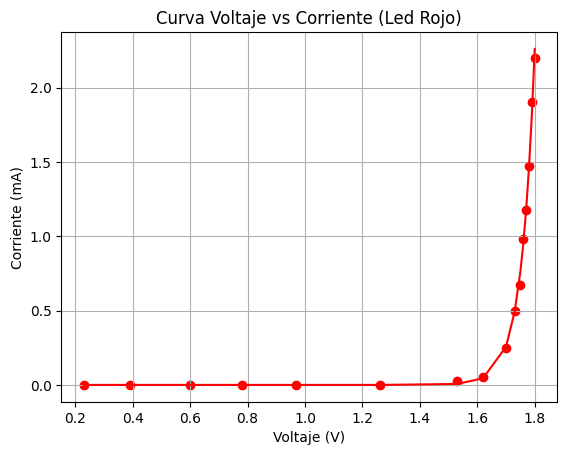

Valor de eta: 1.8575430506951995 y el error es: 0.04958430111752268
I_s es: 2.177080502014656e-17


In [7]:
I_r = np.array([0, 0, 0, 0, 0, 0, 0.025, 0.05, 0.25, 0.5, 0.675, 0.98, 1.175, 1.475, 1.9, 2.2])
V_r = np.array([0.23, 0.39, 0.6, 0.78, 0.97, 1.26, 1.53, 1.62, 1.7, 1.73, 1.75, 1.76, 1.77, 1.78, 1.79, 1.8])

#Valores de referencia
p0 = [3, 1e-12]

#Ajuste no-lineal
poptr, pcovr = curve_fit(intensidad1, V_r, I_r, p0=p0)

#Función del diodo
funcion_rojo = intensidad1(V_r, poptr[0], poptr[1])

#errores
etar_err = np.sqrt(np.diag(pcovr))
#Gráfico
plt.title('Curva Voltaje vs Corriente (Led Rojo)')
plt.plot(V_r, funcion_rojo, color = 'red')
plt.scatter(V_r, I_r, color='red')

plt.xlabel('Voltaje (V)')
plt.ylabel('Corriente (mA)')
plt.grid()
plt.show()

print(f'Valor de eta: {poptr[0]} y el error es: {etar_err[0]}')
print('I_s es:',poptr[1])

## Cálculo de V_e

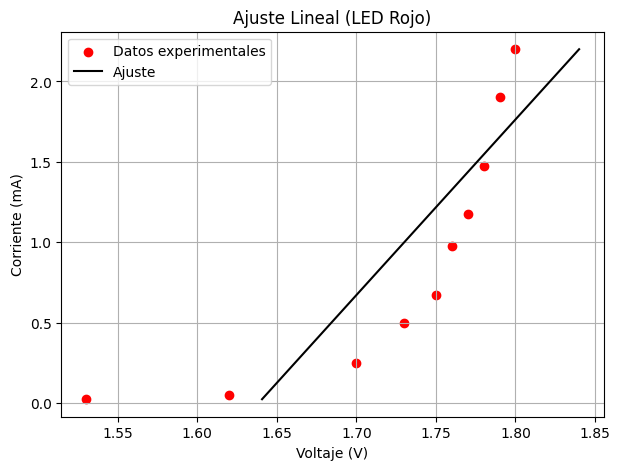

V_r: 1.6384115771381487 +/- 0.027258251316757923 y R_r: 91.64509519160467


In [11]:
I_R = np.array([0.000025, 0.00005, 0.00025, 0.0005, 0.000675, 0.00098, 0.001175, 0.001475, 0.0019, 0.0022])
I_R_mA = I_R * 1e3
V_R = np.array([1.53, 1.62, 1.7, 1.73, 1.75, 1.76, 1.77, 1.78, 1.79, 1.8])

p0 = [2.586, 183]

popt_lin_rojo, pcov_lin_rojo = curve_fit(ajuste_lineal, I_R, V_R, p0 = p0)

lineal_rojo = ajuste_lineal(I_R, popt_lin_rojo[0], popt_lin_rojo[1])

plt.figure(figsize=(7, 5))
plt.title('Ajuste Lineal (LED Rojo)')
plt.scatter(V_R, I_R_mA, color='red', label='Datos experimentales')
plt.plot(lineal_rojo, I_R_mA, color='black', label='Ajuste')

plt.xlabel('Voltaje (V)')
plt.ylabel('Corriente (mA)')
plt.grid(True)
plt.legend()
plt.show()

v_e_err_rojo = np.sqrt(np.diag(pcov_lin_rojo))

print(f'V_r: {popt_lin_rojo[0]} +/- {v_e_err_rojo[0]} y R_r: {popt_lin_rojo[1]}')

## Cálculo de h

In [16]:
lambd_rojo = 730e-9
delta_lambd_rojo = 20e-9
v_e_rojo= 1.63841
delta_ve_rojo = 0.027258
eta_rojo = 1.85754
delta_eta_rojo = 0.049584

h_rojo = calculo_h(lambd_rojo, popt_lin_rojo[0], poptr[0])
err_h_rojo = prop(lambd_rojo, delta_lambd_rojo, v_e_rojo, delta_ve_rojo, eta_rojo, delta_eta_rojo)

print(f'h = ({h_rojo} +/- {err_h_rojo}) Js')


h = (6.571210381615493e-34 +/- 2.0914940657102488e-35) Js


# LED VERDE

## Cálculo de eta

Utilizando el amperímetro

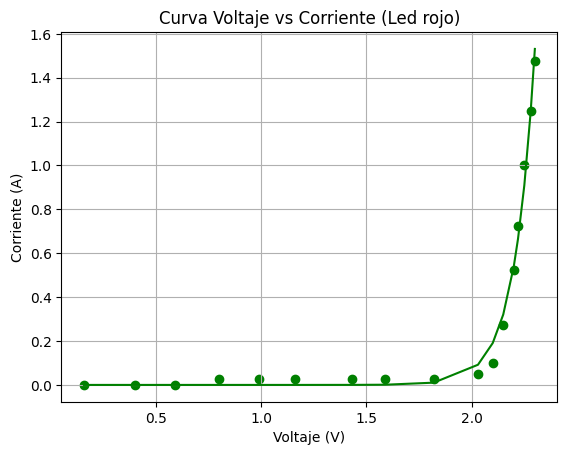

Valor de eta: 3.8815799261808457 y el error es: 0.18600720095362894
I_s es: 6.024092955948987e-11


In [8]:
I_v = np.array([0, 0, 0, 0.025, 0.025, 0.025, 0.025, 0.025, 0.025, 0.05, 0.1, 0.275, 0.525, 0.725, 1, 1.25, 1.475])
V_v = np.array([0.16, 0.4, 0.59, 0.8, 0.99, 1.16, 1.43, 1.59, 1.82, 2.03, 2.1, 2.15, 2.2, 2.22, 2.25, 2.28, 2.3])

#Funcion del diodo
def intensidad1(V_v, eta, I_s):
    V_temp = (constants.k * 287) / constants.e #Calculo la V térmica
    I_v = I_s * (np.exp(V_v / (V_temp * eta)) - 1) #Función del diodo
    return I_v
#Valores de referencia
p0 = [3, 1e-12]

#Ajuste no-lineal
poptv, pcovv = curve_fit(intensidad1, V_v, I_v, p0=p0)

#Función del diodo
funcion_verde = intensidad1(V_v, poptv[0], poptv[1])

#errores
etav_err = np.sqrt(np.diag(pcovv))

#Gráfico
plt.title('Curva Voltaje vs Corriente (Led rojo)')
plt.plot(V_v, funcion_verde, color = 'green')
plt.scatter(V_v, I_v, color='green')

plt.xlabel('Voltaje (V)')
plt.ylabel('Corriente (A)')
plt.grid()
plt.show()

print(f'Valor de eta: {poptv[0]} y el error es: {etav_err[0]}')
print('I_s es:',poptv[1])

## Cálculo de V_e

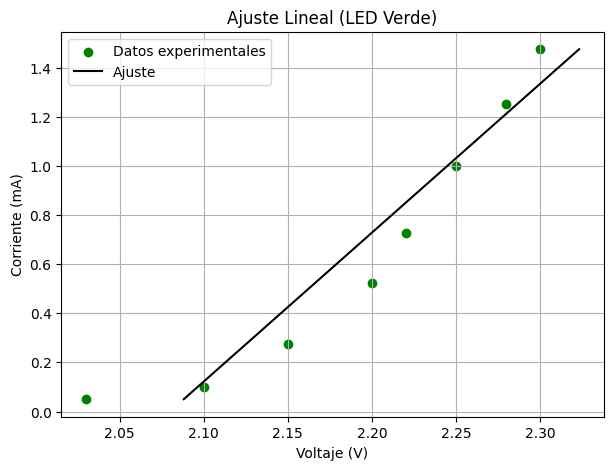

V_v: 2.0799133039398487 +/- 0.01907240237692357 y R_v: 164.94325342244653


In [10]:
I_V_mA = np.array([0.05, 0.1, 0.275, 0.525, 0.725, 1, 1.25, 1.475])
I_V = I_V_mA * 1e-3
V_V = np.array([2.03, 2.1, 2.15, 2.2, 2.22, 2.25, 2.28, 2.3])

p0 = [2.586, 183]

popt_lin_verde, pcov_lin_verde = curve_fit(ajuste_lineal, I_V, V_V, p0 = p0)

lineal_verde = ajuste_lineal(I_V, popt_lin_verde[0], popt_lin_verde[1])

plt.figure(figsize=(7, 5))
plt.title('Ajuste Lineal (LED Verde)')
plt.scatter(V_V, I_V_mA, color='green', label='Datos experimentales')
plt.plot(lineal_verde, I_V_mA, color='black', label='Ajuste')

plt.xlabel('Voltaje (V)')
plt.ylabel('Corriente (mA)')
plt.grid(True)
plt.legend()
plt.show()

v_e_err_verde = np.sqrt(np.diag(pcov_lin_verde))

print(f'V_v: {popt_lin_verde[0]} +/- {v_e_err_verde[0]} y R_v: {popt_lin_verde[1]}')

## Cálculo de h

In [17]:
lambd_verde = 560e-9
delta_lambd_verde = 10e-9
v_e_verde= 2.07991
delta_ve_verde = 0.019072
eta_verde = 3.88157
delta_eta_verde = 0.18600

h_verde = calculo_h(lambd_verde, popt_lin_verde[0], poptv[0])
err_h_verde = prop(lambd_verde, delta_lambd_verde, v_e_verde, delta_ve_verde, eta_verde, delta_eta_verde)

print(f'h = ( {h_verde} +/- {err_h_verde}) Js')

h = ( 6.512068439674128e-34 +/- 1.3026941061497494e-35) Js
